# Student Identification & Submission Details

Please complete the following information before submitting your notebook.

**UNI:**  
**Full Name:**  
**Public GitHub Repository URL (Final Project Report & Code):**

---

## Submission Requirements

- The GitHub repository **must be public**.
- The repository should include:
  - A complete and well-formatted final report
  - Clean, well-documented source code
  - Clear instructions for reproducing results (if applicable)
- Verify that all links are functional and accessible prior to submission.

# Project Submission Guidelines

### Submission Due Date: March 9, 2026

Throughout this notebook, you will encounter the keyword **`TODO`** in multiple sections. Each `TODO` indicates a required component that must be completed by you.

These may include:

- Implementing missing code
- Specifying or tuning model parameters
- Writing explanations and technical reasoning
- Performing analysis and interpreting results
- Justifying modeling decisions
- Completing evaluation procedures

---

## Expectations

You are expected to:

- Replace **every** `TODO` with correct, fully functional code.
- Provide complete, clear, and technically sound explanations where required.
- Justify modeling choices using appropriate reasoning and evidence.
- Ensure the notebook executes from start to finish **without errors**.

> **Note:** Any section that still contains `TODO` at the time of submission will be considered **incomplete**.

# World Happiness Classification Competition

## Project Objectives

This competition is designed to help you:

- Develop a deep understanding of how machine learning models function
- Understand the role and impact of model hyperparameters
- Learn from systematic experimentation and model iteration
- Produce a professional, well-structured notebook report
- Publish the final project as a portfolio-ready GitHub repository

---

## Project Workflow

You will complete the project through the following stages:

1. **Load and Merge Datasets**  
   - Import all relevant datasets  
   - Perform necessary joins and validation  

2. **Data Preprocessing**  
   - Build preprocessing pipelines using `sklearn`'s `ColumnTransformer`  
   - Handle missing values, encoding, scaling, and feature engineering  

3. **Model Training**  
   - Fit the model using the processed data  
   - Save both the preprocessing pipeline and trained model  

4. **Prediction and Evaluation**  
   - Generate predictions  
   - Evaluate performance using appropriate metrics  

5. **Hyperparameter Tuning**  
   - Systematically tune model parameters  
   - Compare performance across configurations  

6. **Deep Learning Experimentation**  
   - Implement and evaluate a neural network approach  
   - Compare results with classical ML models  

7. **Model Explainability (SHAP)**  
   - Apply SHAP for feature importance analysis  
   - Interpret and explain model decisions  

8. **Final Report Submission**  
   - Clean and organize the notebook  
   - Ensure full reproducibility  
   - Upload the final report and code to a public GitHub repository  

---

## 0. Loading Datasets

In this section, we load the **World Happiness 2023** datasets that will be used throughout the project.

**Objectives of this stage:**

- Import the datasets into the notebook environment
- Inspect their structure and contents
- Verify column names and data types
- Identify potential inconsistencies before merging

> Careful dataset inspection at this stage prevents downstream errors and ensures a clean modeling pipeline.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split

# Load the dataset
whr_df = pd.read_csv('data/WHR_2023.csv')

# Inspect the first few rows to understand the structure
whr_df


,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,Finland,Western Europe,7.804,1.888,1.585,0.535,0.772,0.126,0.535
1,Denmark,Western Europe,7.586,1.949,1.548,0.537,0.734,0.208,0.525
2,Iceland,Western Europe,7.530,1.926,1.620,0.559,0.738,0.250,0.187
3,Israel,Middle East and North Africa,7.473,1.833,1.521,0.577,0.569,0.124,0.158
4,Netherlands,Western Europe,7.403,1.942,1.488,0.545,0.672,0.251,0.394
...,...,...,...,...,...,...,...,...,...
132,Congo (Kinshasa),Sub-Saharan Africa,3.207,0.531,0.784,0.105,0.375,0.183,0.068
133,Zimbabwe,Sub-Saharan Africa,3.204,0.758,0.881,0.069,0.363,0.112,0.117
134,Sierra Leone,Sub-Saharan Africa,3.138,0.670,0.540,0.092,0.371,0.193,0.051
135,Lebanon,Middle East and North Africa,2.392,1.417,0.476,0.398,0.123,0.061,0.027


In [26]:
# Convert the regression target ('happiness_score') into classification labels
# We'll use quartiles to create 4 happiness categories: Very Low, Low, High, Very High

# Define quartiles
whr_df['happiness_category'] = pd.qcut(whr_df['happiness_score'],
                                       q=5,
                                       labels=['Very Low', 'Low','Average', 'High', 'Very High'])

# Select features and target
X = whr_df.drop(columns=['happiness_score', 'happiness_category'])
y = whr_df['happiness_category']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Convert y_train and y_test to numerical labels
y_train_labels = y_train.astype('category').cat.codes

y_test_labels = y_test.astype('category').cat.codes


### Conceptual Question

In the next cell, briefly explain the following:

1. What does `y_train.astype('category').cat.codes` do?
2. What is the difference between `y_train_labels` and `y_train`?

Keep your explanation clear and concise.

*Replace this section with your response.*

**TODO**

y_train is the features used to train the model. 

1. y_test.astype('category') -- converts y_test ('happiness_category') into a pandas Categorical dtype

y_test.cat.codes assigns integer codes (0 - 4) by position in the stored category list, with 0 as "very low" and 4 into "very high". Used as a preprocessing step for to convert cateogories to numeric codes for machine learning algorithms. 

2. y_train are raw categorical strings, with order meta data. (e.g.   Finland      Very High)

y_train_labels are label vectors, plain integers derived / encoded labels from y_train with no meta data (e.g.   Finland      4)


### Add New Data

In [27]:
# Truncated and cleaned up region data to merge
countrydata=pd.read_csv("data/newcountryvars.csv")

countrydata.head()

,country_name,population,population_below_poverty_line,hdi,life_expectancy,expected_years_of_schooling,mean_years_of_schooling,gni
0,India,1339180127,21.9,0.623559,68.322,11.696590,6.298834,5663.474799
1,Nigeria,190886311,70.0,0.527105,53.057,9.970482,6.000000,5442.901264
2,Mexico,129163276,46.2,0.761683,76.972,13.299090,8.554985,16383.106680
3,Pakistan,197015955,29.5,0.550354,66.365,8.106910,5.089460,5031.173074
4,Bangladesh,164669751,31.5,0.578824,71.985,10.178706,5.241577,3341.490722


In [28]:
# Merge in new data to X_train and X_test by taking "country" from first table and "country_name" from 2nd table.
# Also check which countries are common in both the datasets, and which type of merge will you perform for the best results.
# Hint: Look on the 'how' parameter of megre function of pandas.

X_train = X_train.merge(countrydata, left_on='country', right_on='country_name',how='left').drop(columns='country_name')
X_test = X_test.merge(countrydata, left_on='country', right_on='country_name', how='left').drop(columns='country_name')

common = set(X_train['country']) & set(X_test['country'])

In [29]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train.head(1)

X_train shape: (95, 15)
X_test shape: (42, 15)


,country,region,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,population,population_below_poverty_line,hdi,life_expectancy,expected_years_of_schooling,mean_years_of_schooling,gni
0,Madagascar,Sub-Saharan Africa,0.632,0.779,0.178,0.187,0.177,0.134,25570895.0,70.7,0.512149,65.515,10.34614,6.145955,1319.699397


---

## 1. Exploratory Data Analysis and Visualization (EDAV)

In [30]:
print(X_train.dtypes)

country                           object
region                            object
gdp_per_capita                   float64
social_support                   float64
healthy_life_expectancy          float64
freedom_to_make_life_choices     float64
generosity                       float64
perceptions_of_corruption        float64
population                       float64
population_below_poverty_line    float64
hdi                              float64
life_expectancy                  float64
expected_years_of_schooling      float64
mean_years_of_schooling          float64
gni                              float64
dtype: object


### Describe What You Observe

*Replace this section with your response.*


**Answer:** 
- After the merge operation, we get a clearer view and understanding of the given countries across more features. This is evidenced by the increase of the number of columns for the countries from 8 as seen before the merge to 15 columns. We further get better understanding of the countries and regions, especially because after the merge we see the regions column introduced which enhances our understanding of the data beyond the country level.

- Happiness_score and happiness_category are excluded since they're the target variable. Inclusion would cause data leakage. 

- clean merge with no _x/_y suffix columns. This confirms the clean up worked

- country and region columns are strings and need encoding. (e.g. one-hot or label encoding) before feeding into ML model. 

- some float64 columns may need scaling (e.g. features such as gdp_per_capita and generosity) are on different scales. We may need to normalise or standardise. 



### Missing Values Analysis

Compute the number and percentage of missing values for each column and present the results in a clear summary table.

In [31]:
# Your code here: TODO
# update - consider merged, we have tons of missing values for the newcountrys
missing = X_train.isnull().sum()
missing_percent = 100 * missing / len(X_train)
missing_table = pd.concat([missing, missing_percent], axis=1)
missing_table

# print(missing_percent)
# print(missing_table)

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_percent
}).sort_values(by='Missing Values', ascending=False)
print("Missing Values Summary Train Set:")
display(missing_df[missing_df['Missing Values'] > 0])

missing_test = X_test.isnull().sum()
missing_percent_test = 100 * missing_test / len(X_test)
missing_table = pd.concat([missing_test, missing_percent_test], axis=1)
missing_table
#print(missing_percent_test)
missing_df2 = pd.DataFrame({
    'Missing Values': missing_test,
    'Percentage (%)': missing_percent_test
}).sort_values(by='Missing Values', ascending=False)
print("Missing Values Summary Test Set:")
display(missing_df2[missing_df2['Missing Values'] > 0])# Your code here: TODO

Missing Values Summary Train Set:


,Missing Values,Percentage (%)
population_below_poverty_line,16,16.842105
life_expectancy,7,7.368421
expected_years_of_schooling,7,7.368421
mean_years_of_schooling,7,7.368421
gni,7,7.368421
population,6,6.315789
hdi,6,6.315789


Missing Values Summary Test Set:


,Missing Values,Percentage (%)
population,3,7.142857
population_below_poverty_line,3,7.142857
hdi,3,7.142857
life_expectancy,3,7.142857
expected_years_of_schooling,3,7.142857
mean_years_of_schooling,3,7.142857
gni,3,7.142857
healthy_life_expectancy,1,2.380952


### Distribution of Key Numerical Features

Select relevant numerical features and plot their histograms. Choose features that may influence the target variable, and briefly comment on notable patterns, skewness, or outliers.

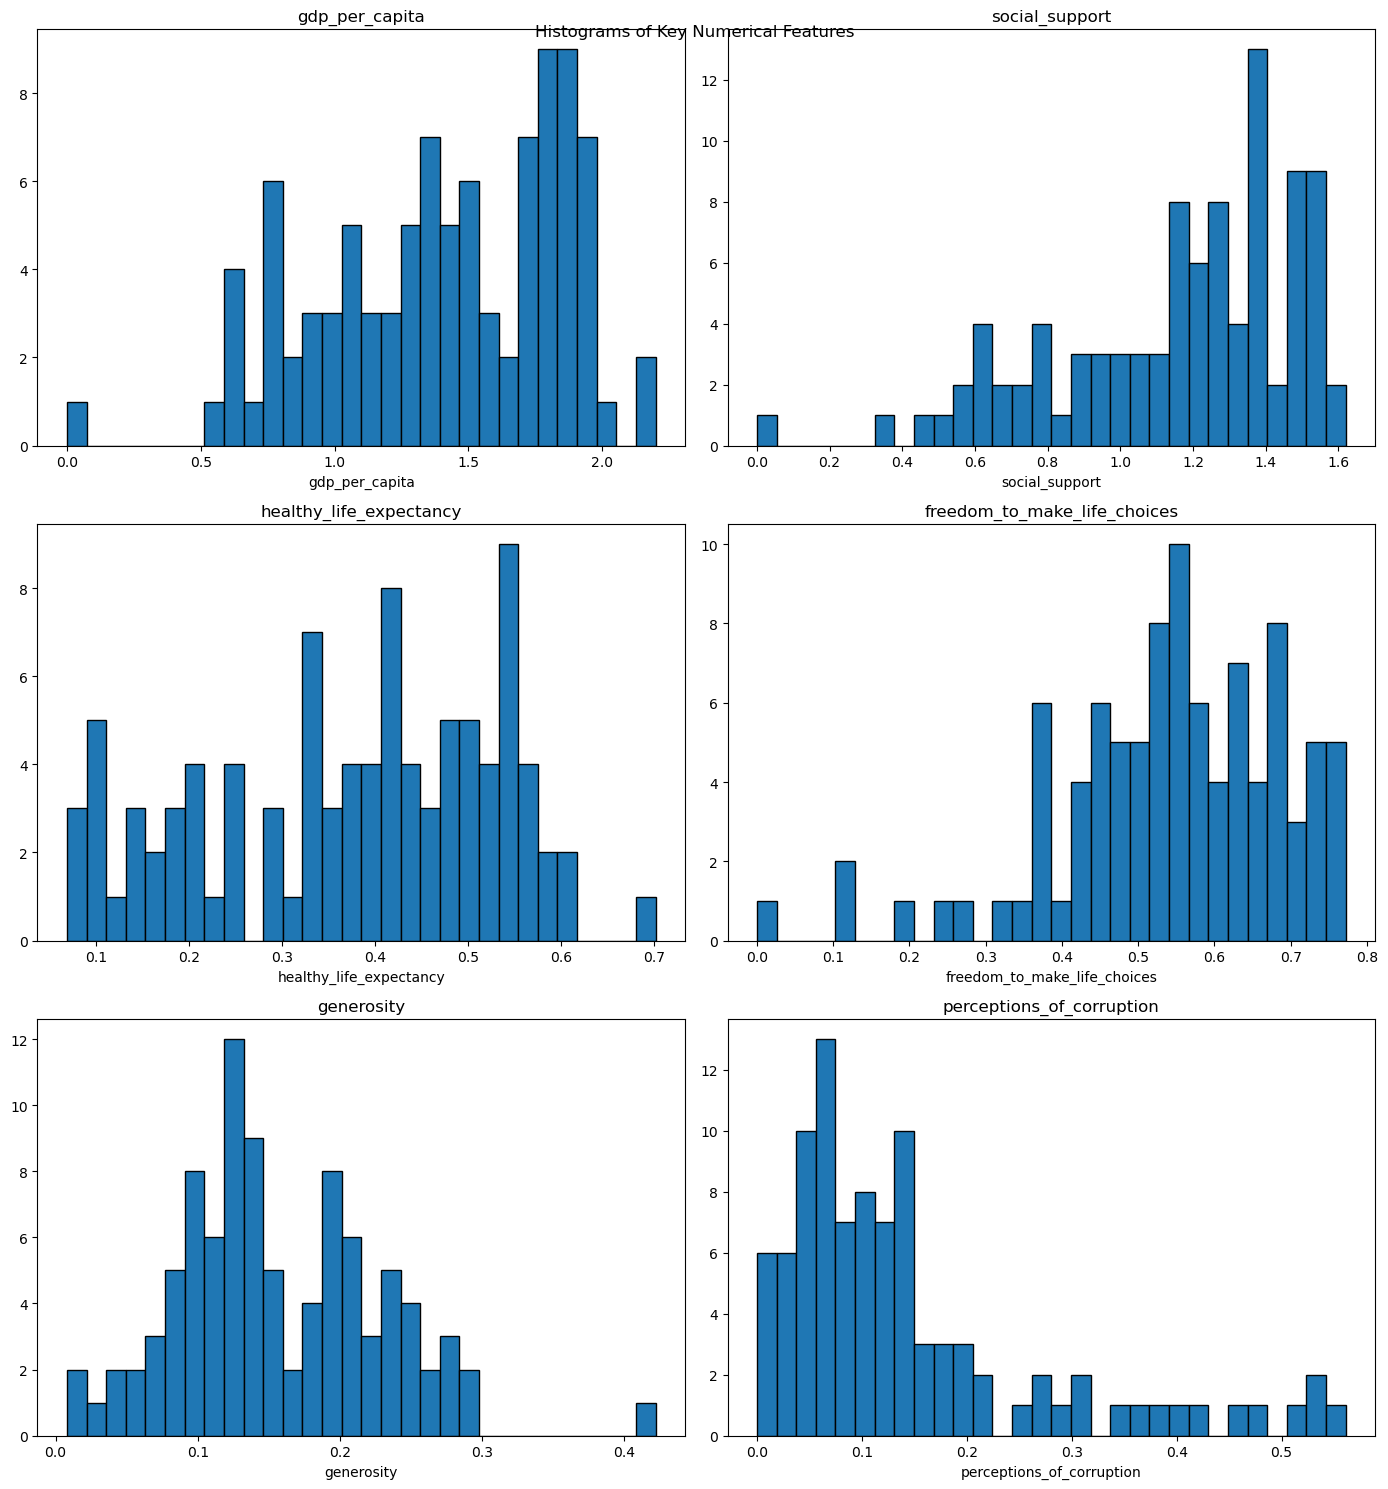

In [32]:
# Your plotting code here: TODO
# key numerical values: gdp_per_capita, social_support, healthy_life_expectancy, freedom_to_make_life_choices, generosity, perceptions_of_corruption, population, population_below_poverty_line, hdi, life_expectancy, expected_years_of_schooling, mean_years_of_schooling, gni                            

import math

num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
key_features = [c for c in num_cols if c in[
  'gdp_per_capita',
  'social_support',
  'healthy_life_expectancy',
  'freedom_to_make_life_choices',
  'generosity',
  'perceptions_of_corruption'  
]]

if not key_features: 
    key_features = num_cols

ncols = 2
nrows = math.ceil(len(key_features) / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 5 * nrows))
axes = axes.flatten()

for i, col in enumerate(key_features):
    if i < len(axes):
        axes[i].hist(X_train[col].dropna(), bins=30, edgecolor='black')
        axes[i].set_title(col)
        axes[i].set_xlabel(col)

for j in range(len(key_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle('Histograms of Key Numerical Features')
plt.show()

**Notable patterns, skewness and outliers:**
- **Skewness:** GDP per capita and other economic/development variables are typically right-skewed (long upper tail): many countries at lower values, fewer at high values. Bounded indicators (e.g. social support, freedom, perceptions of corruption, often on 0–1 scales) may show left skew (mass near the high end) or mild right skew.

- Most skewed: social_support (left skewed), freedom_to_make_life_choices (left skewed), and perceptions_of_corruption (right skewed) are the most skewed. Suggests that transformations may help linear models

- gdp_per_capita's bimodal distribution (peaks around 1.0 and 1.7).  No extreme outliers but a wide  spread. Suggests two groups of countries (developing vs developed). May be a strong class separator

- generosity is the most symmetrically / normally distributed and has the
  narrowest range (0.10 - 0.15), with one high outlier (near 0.45).

- social_support has heavy left-skew and concentration (1.2–1.6), with one outlier near 0. Suggests most countries report strong social support, with a few struggling nations pulling the left tail.

- healthy_life_expectancy is roughly ultimodal, peaks around
  0.45–0.50, with notable cluster at 0.05–0.10. Suggesting low life
  expectancy countries. Wide spread with a slight right skew.

- freedom_to_make_life_choices — Left-skewed, concentrated
  between 0.4–0.8. A sparse low-value tail (0.0–0.2). Most
  countries cluster toward higher freedom scores.

- - **Outliers:** A small number of countries often sit at the extremes (e.g. very high GDP or very low generosity/corruption). These can affect means and some models; robust scaling or winsorization may help if they dominate.




Features Chosen: 
- gdp_per_capita
- social_support
- healthy_life_expectancy
- freedom_to_make_life_choices
- generosity
- perceptions_of_corruption



### Distribution of Categorical Variables

Plot the distribution of relevant categorical variables using appropriate visualizations (e.g., count plots or bar charts). Briefly comment on class imbalance or notable patterns.

(0.0, 27.0)

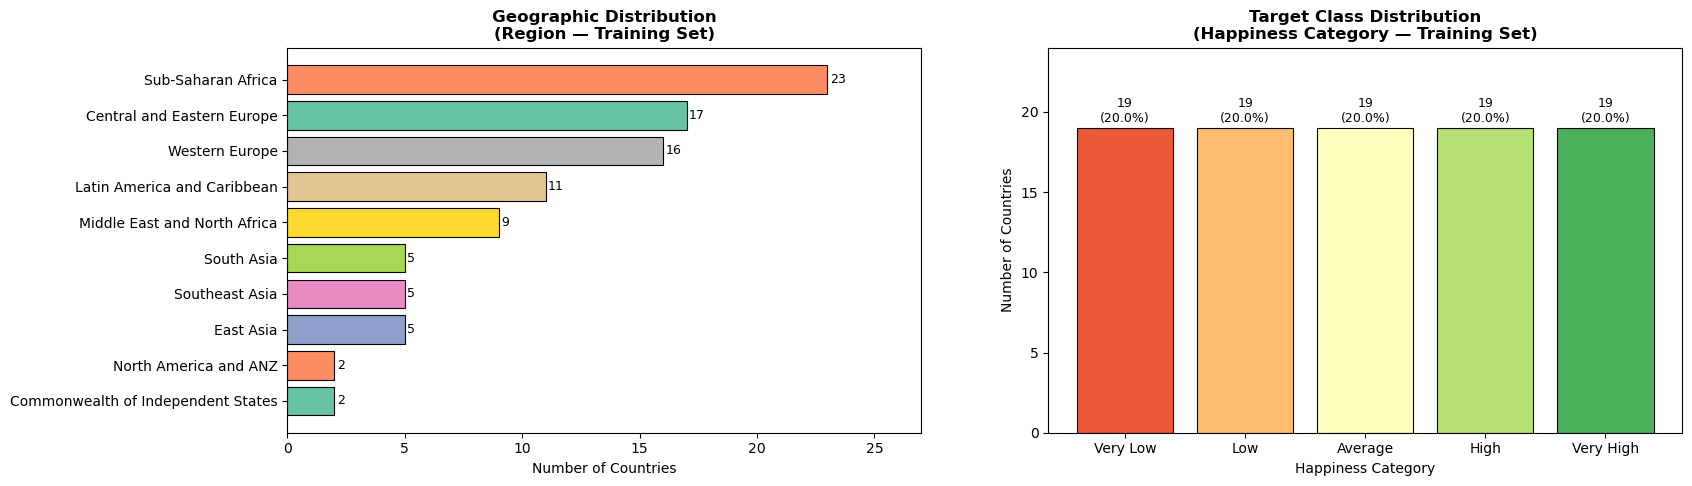

In [33]:
# Your plotting code(s) here: TODO
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
category_order = ['Very Low', 'Low', 'Average', 'High', 'Very High']
label_counts   = y_train.value_counts().reindex(category_order, fill_value=0)
total          = label_counts.sum()
bars = axes[1].bar(
    label_counts.index,
    label_counts.values,
    color=sns.color_palette('RdYlGn', len(category_order)),
    edgecolor='black',
    linewidth=0.8,
)

for bar, count in zip(bars, label_counts.values):
   pct = 100 * count / total
   axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{count}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=9,
    )

axes[1].set_title('Target Class Distribution\n(Happiness Category — Training Set)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Happiness Category', fontsize=10)
axes[1].set_ylabel('Number of Countries', fontsize=10)
axes[1].set_ylim(0, label_counts.max() + 5)


region_counts = X_train['region'].value_counts().sort_values(ascending=True)

axes[0].barh(
    region_counts.index,
    region_counts.values,
    color=sns.color_palette('Set2', len(region_counts)),
    edgecolor='black',
    linewidth=0.8,
)

# Annotate with count so exact numbers are readable without gridlines
for idx, count in enumerate(region_counts.values):
    axes[0].text(count + 0.1, idx, str(count), va='center', fontsize=9)

axes[0].set_title('Geographic Distribution\n(Region — Training Set)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Countries', fontsize=10)
axes[0].set_xlim(0, region_counts.max() + 4)



### Feature Correlation Analysis

Analyze the relationships between numerical features using correlation coefficients. Compute and visualize:

- **Pearson correlation** — linear relationships
- **Spearman correlation** — monotonic relationships
- **Kendall correlation** — rank-based relationships

Use correlation matrices and heatmaps where appropriate. Briefly interpret strong positive or negative correlations and discuss potential multicollinearity.

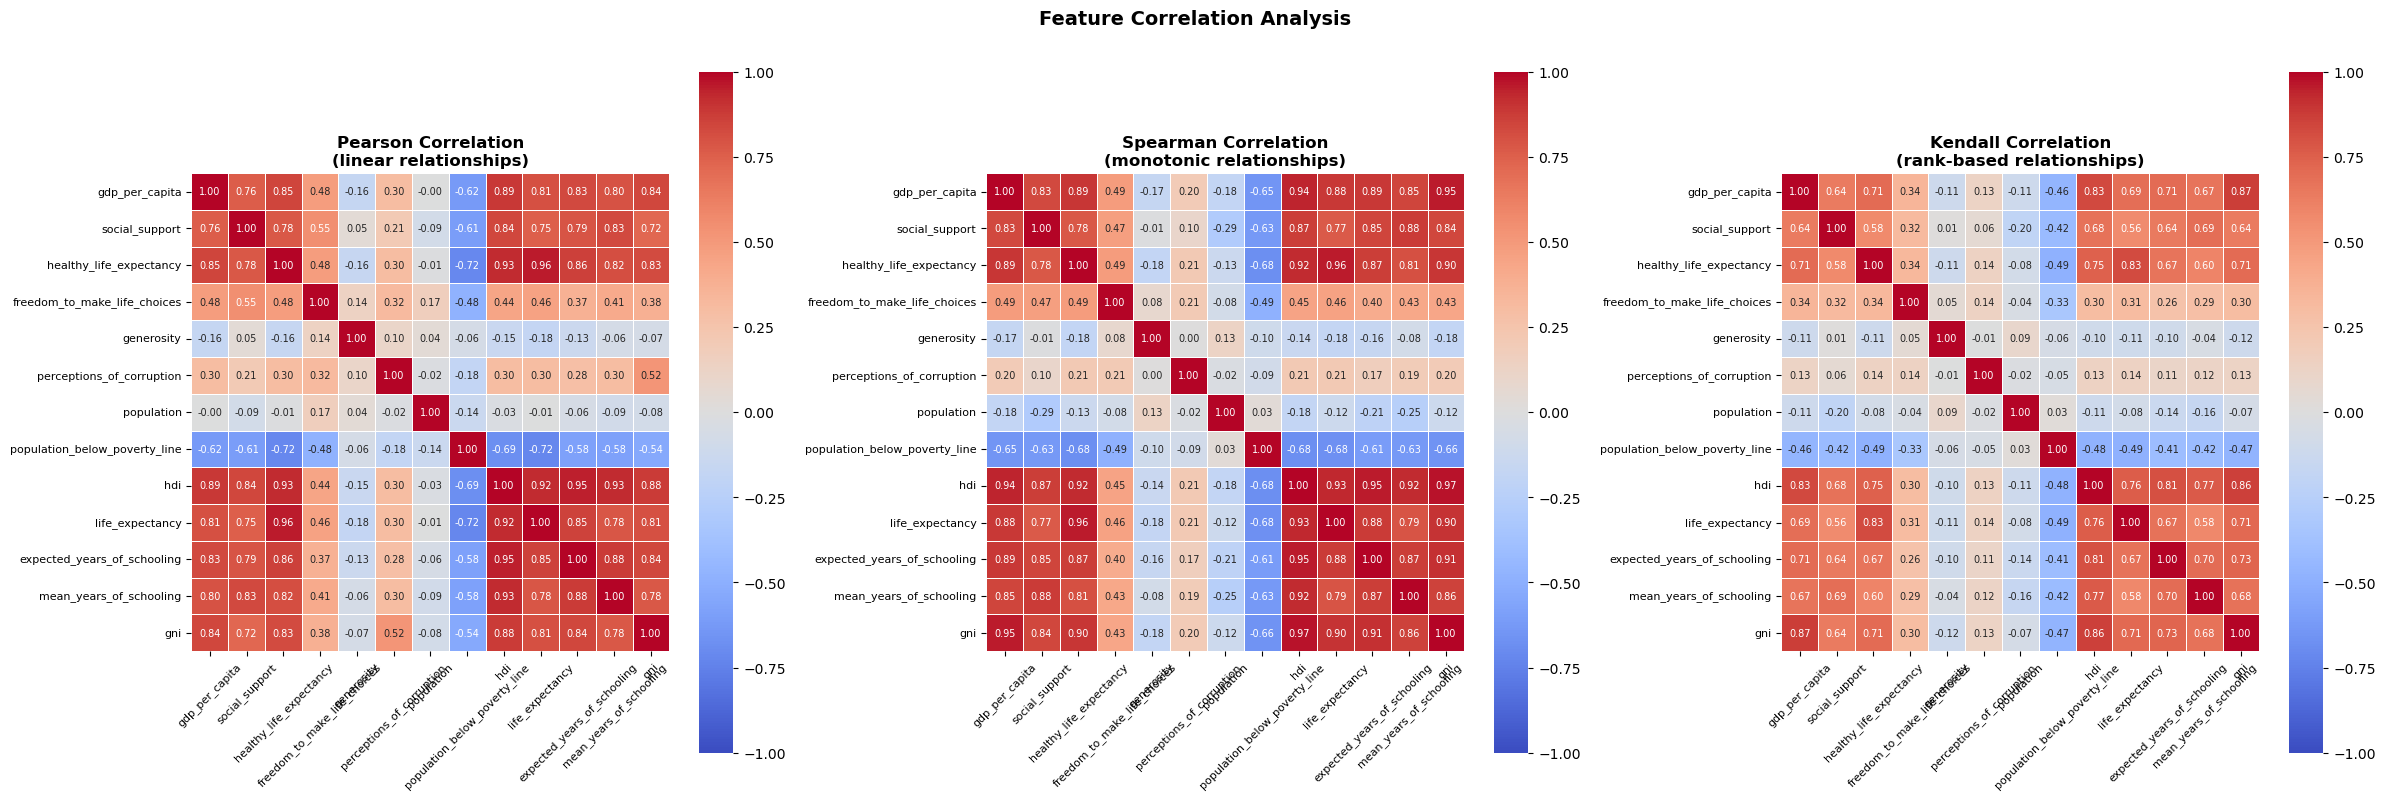

Top 10 Spearman correlations (excluding self-correlations):
hdi                          gni                            0.972306
gni                          hdi                            0.972306
life_expectancy              healthy_life_expectancy        0.958141
healthy_life_expectancy      life_expectancy                0.958141
expected_years_of_schooling  hdi                            0.953793
hdi                          expected_years_of_schooling    0.953793
gdp_per_capita               gni                            0.953552
gni                          gdp_per_capita                 0.953552
hdi                          gdp_per_capita                 0.940337
gdp_per_capita               hdi                            0.940337


In [34]:
import numpy as np
 
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_df = X_train[num_cols].dropna()

pearson  = num_df.corr(method='pearson')
spearman = num_df.corr(method='spearman')
kendall  = num_df.corr(method='kendall')

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

heatmap_kwargs = dict(
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='coolwarm', vmin=-1, vmax=1,
    linewidths=0.5, square=True
)

sns.heatmap(pearson,  ax=axes[0], **heatmap_kwargs)
axes[0].set_title('Pearson Correlation\n(linear relationships)', fontsize=12, fontweight='bold')

sns.heatmap(spearman, ax=axes[1], **heatmap_kwargs)
axes[1].set_title('Spearman Correlation\n(monotonic relationships)', fontsize=12, fontweight='bold')

sns.heatmap(kendall,  ax=axes[2], **heatmap_kwargs)
axes[2].set_title('Kendall Correlation\n(rank-based relationships)', fontsize=12, fontweight='bold')

for ax in axes:
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('Feature Correlation Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print top correlations (Spearman — most reliable for this dataset)
print("Top 10 Spearman correlations (excluding self-correlations):")
spearman_pairs = (
    spearman.where(~np.eye(len(spearman), dtype=bool))
    .stack()
    .abs()
    .sort_values(ascending=False)
)
print(spearman_pairs.head(10).to_string())


###Brief interpretations of correlations and collinearity

From the histograms earlier, we note that most features are skewed (gdp_per_capita, perceptions_of_corruption, generosity are all right-skewed). 
  
Pearson assumes i) variables are normally distributed, ii) relationship is strictly linear. Neither is true here. 

Spearman converts values to ranks first, neutralising skews and outliers. This makes making it robust for this dataset especially with n = 95. 

Kendall also uses ranks but is conservative and suited to small samples with many ties.

---

###Interpretation from heatmaps

Strong positive correlations (all three methods agree, as evident from the dark red):
  - hdi strong correlation (~0.8–0.95) with life_expectancy, mean_years_of_schooling, expected_years_of_schooling

  - gdp_per_capita correlates with healthy_life_expectancy, hdi, gni. Sugggest wealthier countries have better health and development outcomes
  - healthy_life_expectancy correlates with life_expectancy. near-duplicate features

Weak/negative correlations:
  - generosity correlates with most other features. But near-zero correlations throughout, suggesting its independence 
  - perceptions_of_corruption shows inconsistent correlations behaves differently across the three methods, suggesting a non-monotonic or noisy relationship


### Bivariate Analysis and Relationship Exploration

Explore relationships between features and examine how they associate with the target variable. Include:

- Bivariate plots (e.g., scatter plots, box plots, grouped bar charts)
- Correlation tables
- Comparisons of feature distributions across target classes

Briefly summarize key relationships and any patterns that may influence model performance.

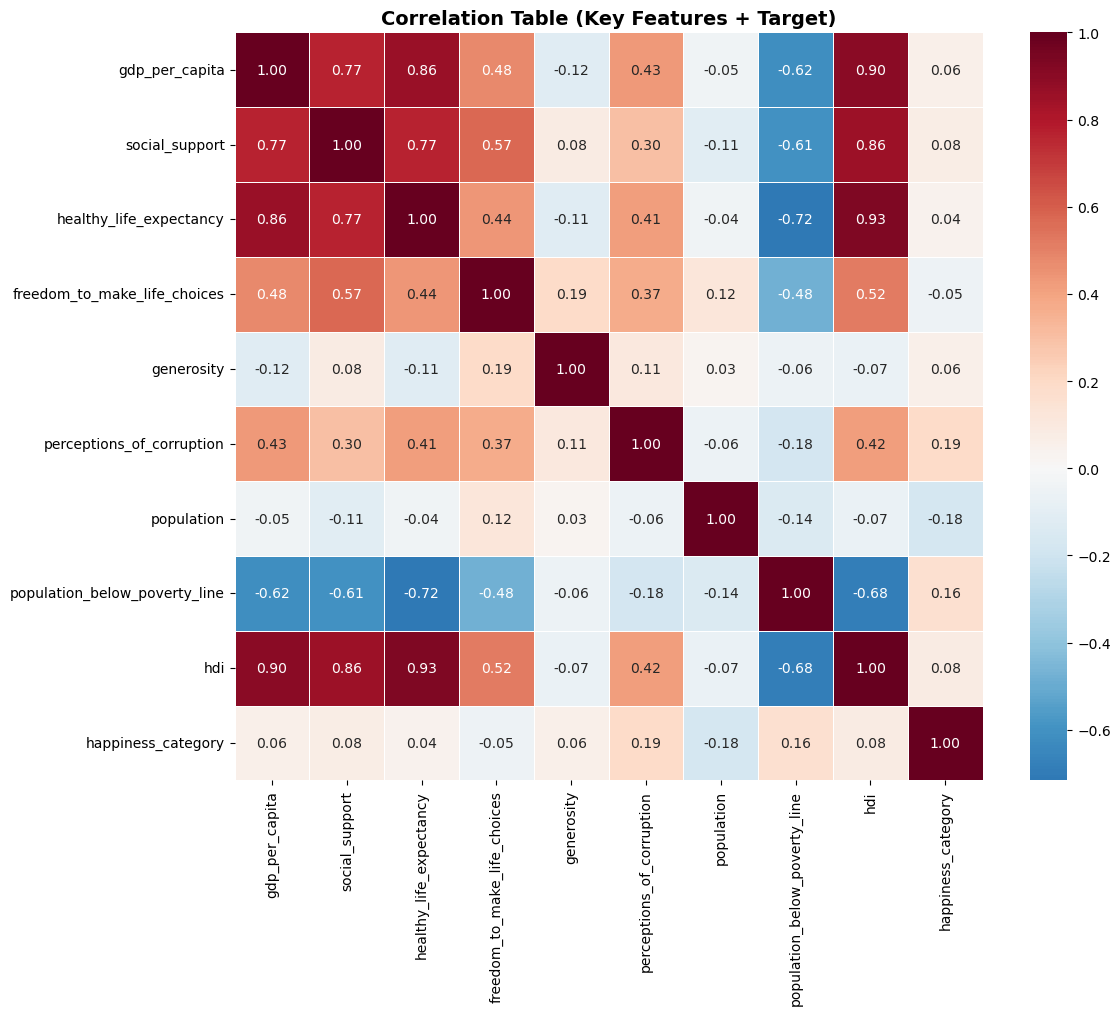

Correlation with target (happiness_category):
perceptions_of_corruption        0.189
population_below_poverty_line    0.160
hdi                              0.083
social_support                   0.078
gdp_per_capita                   0.059
generosity                       0.058
healthy_life_expectancy          0.043
freedom_to_make_life_choices    -0.046
population                      -0.180


/var/folders/xr/sd9f3z_532b38h7gcj2bs7440000gn/T/ipykernel_97595/655118091.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp, x='happiness_category', y=col, order=category, palette='RdYlGn', ax=axes[i])
/var/folders/xr/sd9f3z_532b38h7gcj2bs7440000gn/T/ipykernel_97595/655118091.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp, x='happiness_category', y=col, order=category, palette='RdYlGn', ax=axes[i])
/var/folders/xr/sd9f3z_532b38h7gcj2bs7440000gn/T/ipykernel_97595/655118091.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

 

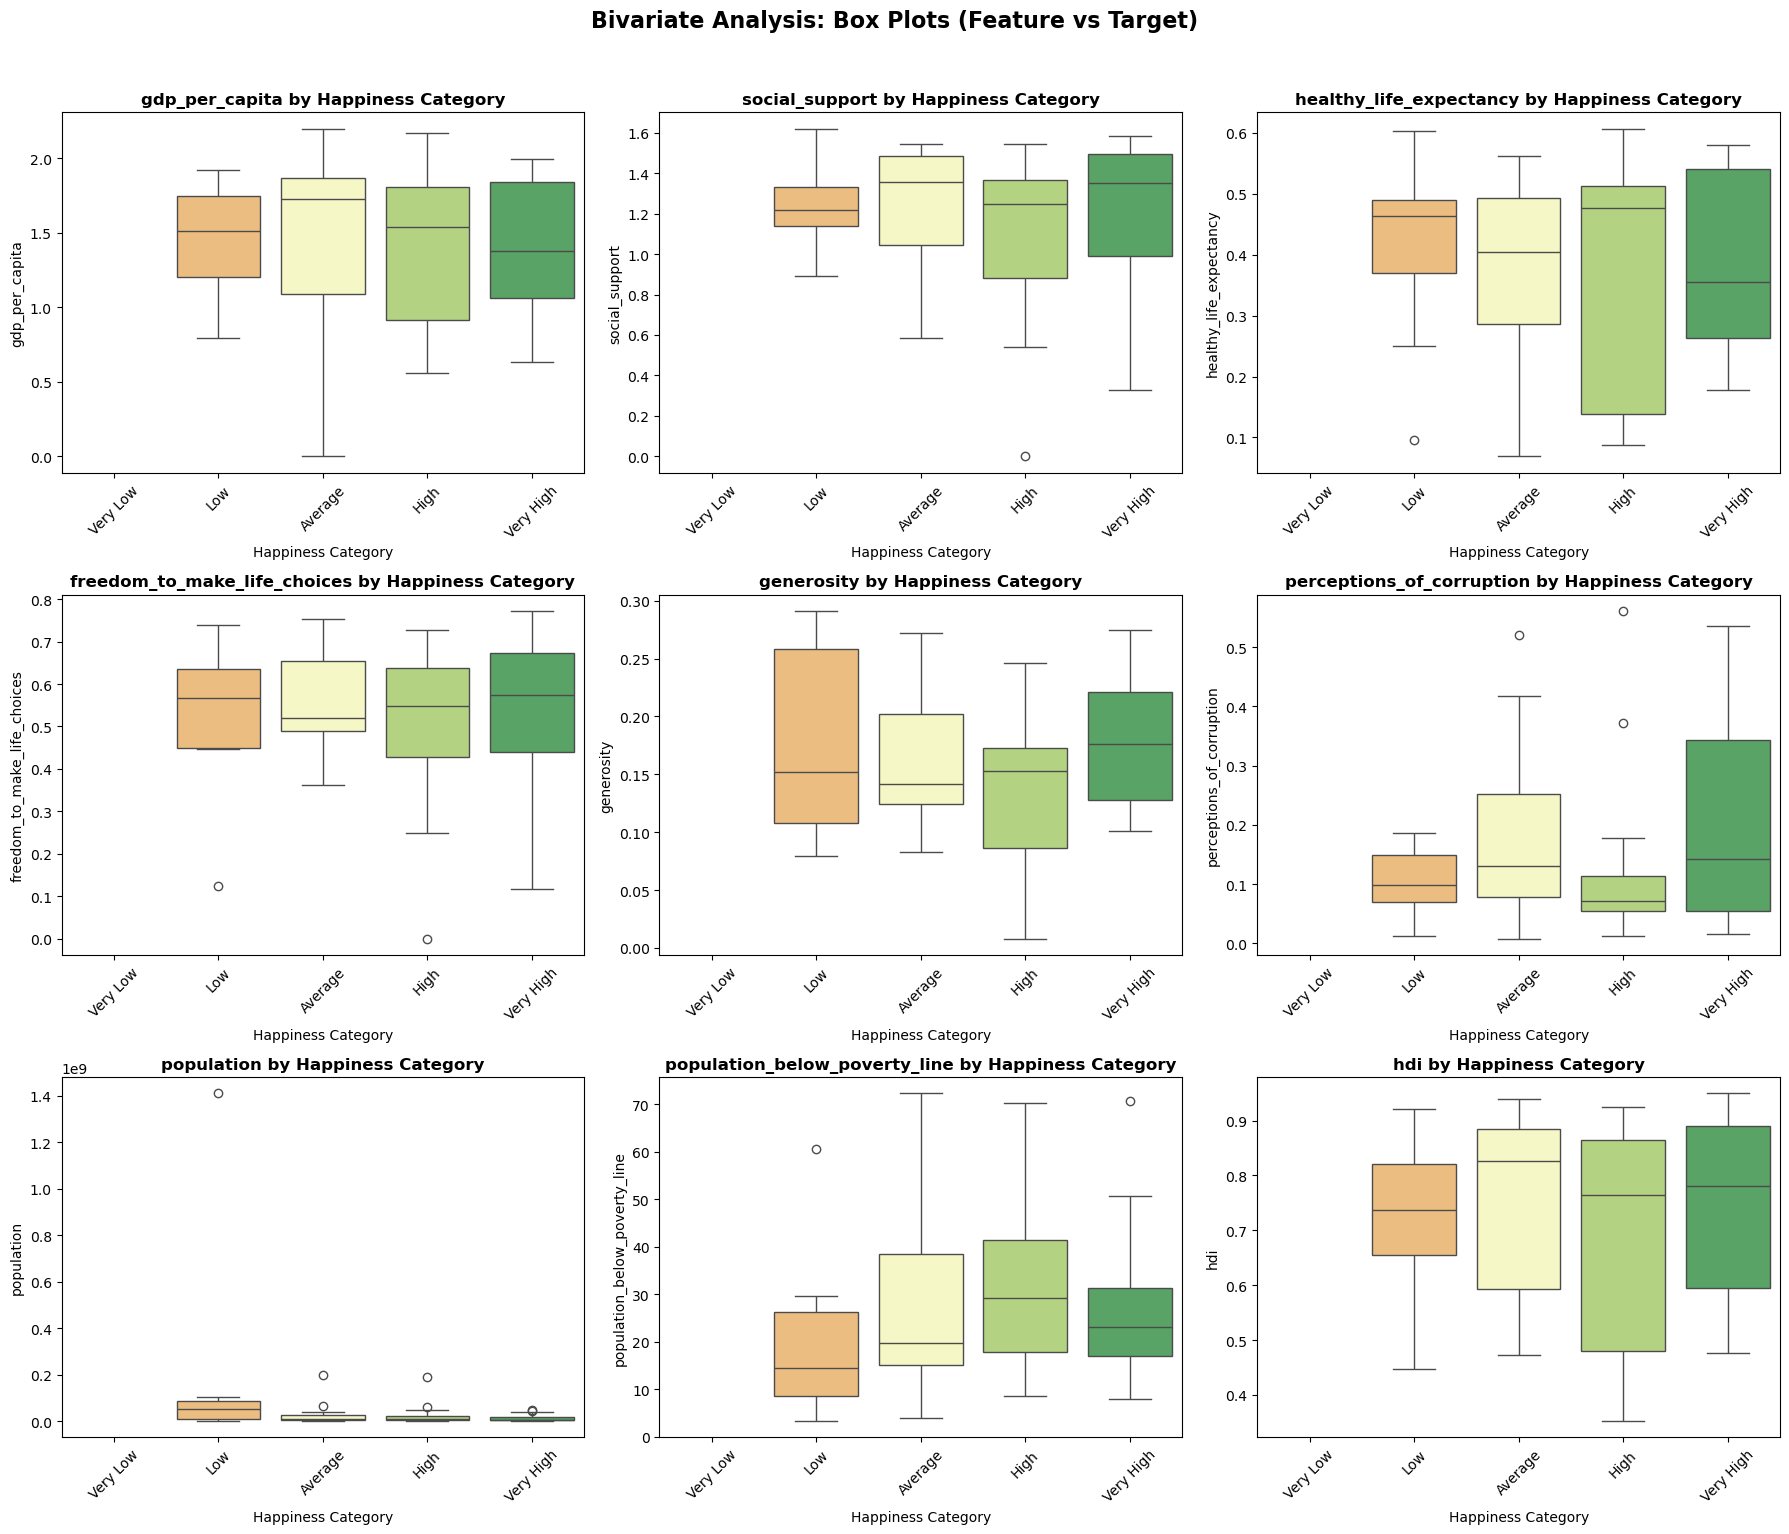

/var/folders/xr/sd9f3z_532b38h7gcj2bs7440000gn/T/ipykernel_97595/655118091.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=temp, x='happiness_category', y=col, order=category, palette='RdYlGn', jitter=0.25, size=6, alpha=0.6, ax=axes[i], edgecolor='black', linewidth=0.5)
/var/folders/xr/sd9f3z_532b38h7gcj2bs7440000gn/T/ipykernel_97595/655118091.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=temp, x='happiness_category', y=col, order=category, palette='RdYlGn', jitter=0.25, size=6, alpha=0.6, ax=axes[i], edgecolor='black', linewidth=0.5)
/var/folders/xr/sd9f3z_532b38h7gcj2bs7440000gn/T/ipykernel_97595/655118091.py:51: FutureWarning: 

Passing `palette` without assig

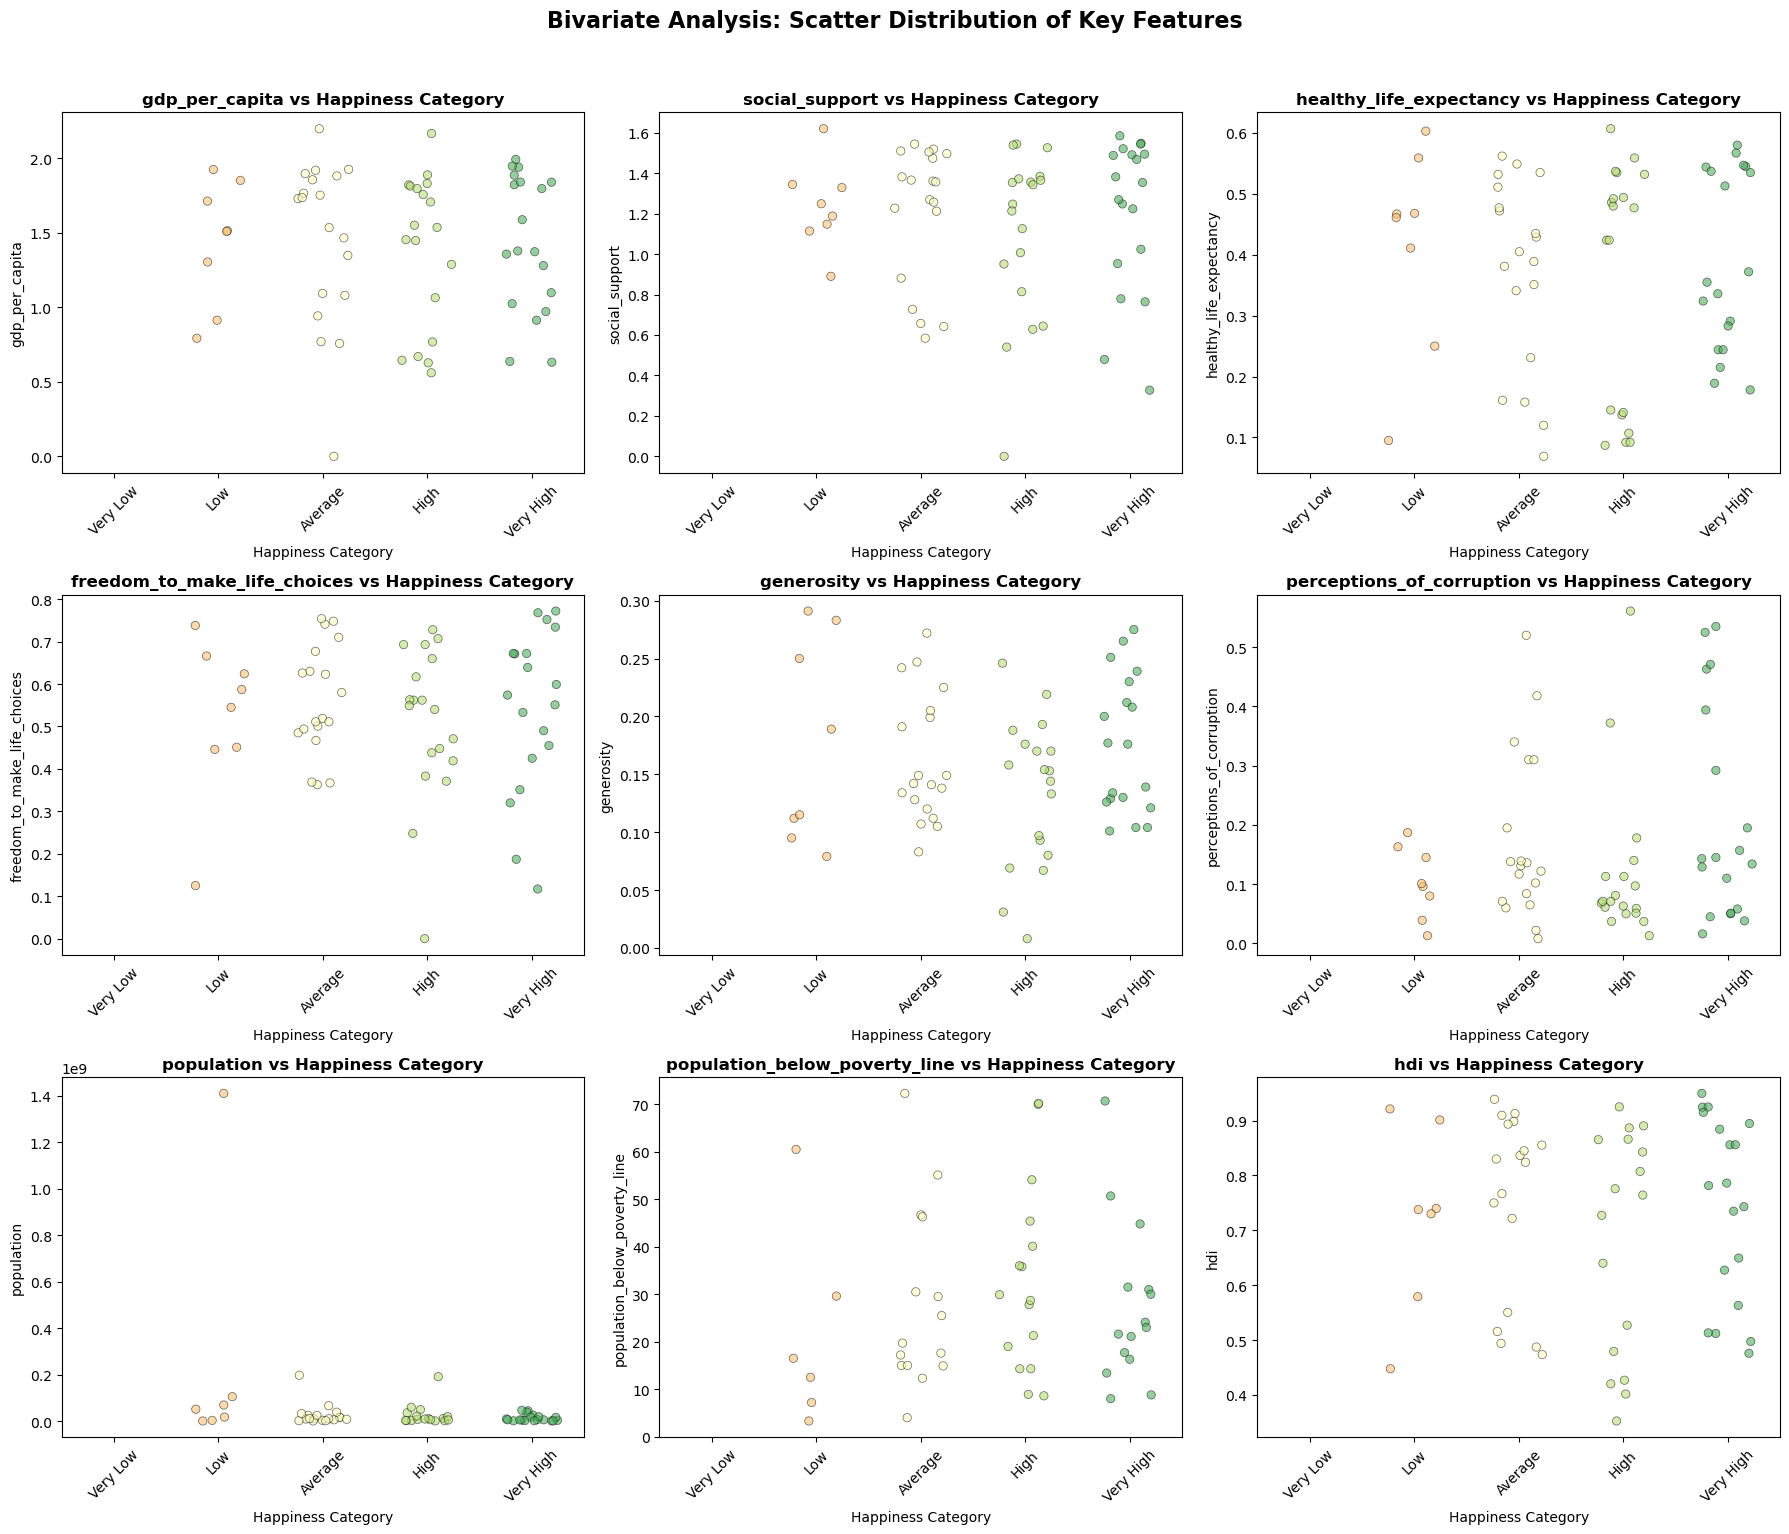

/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:902: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


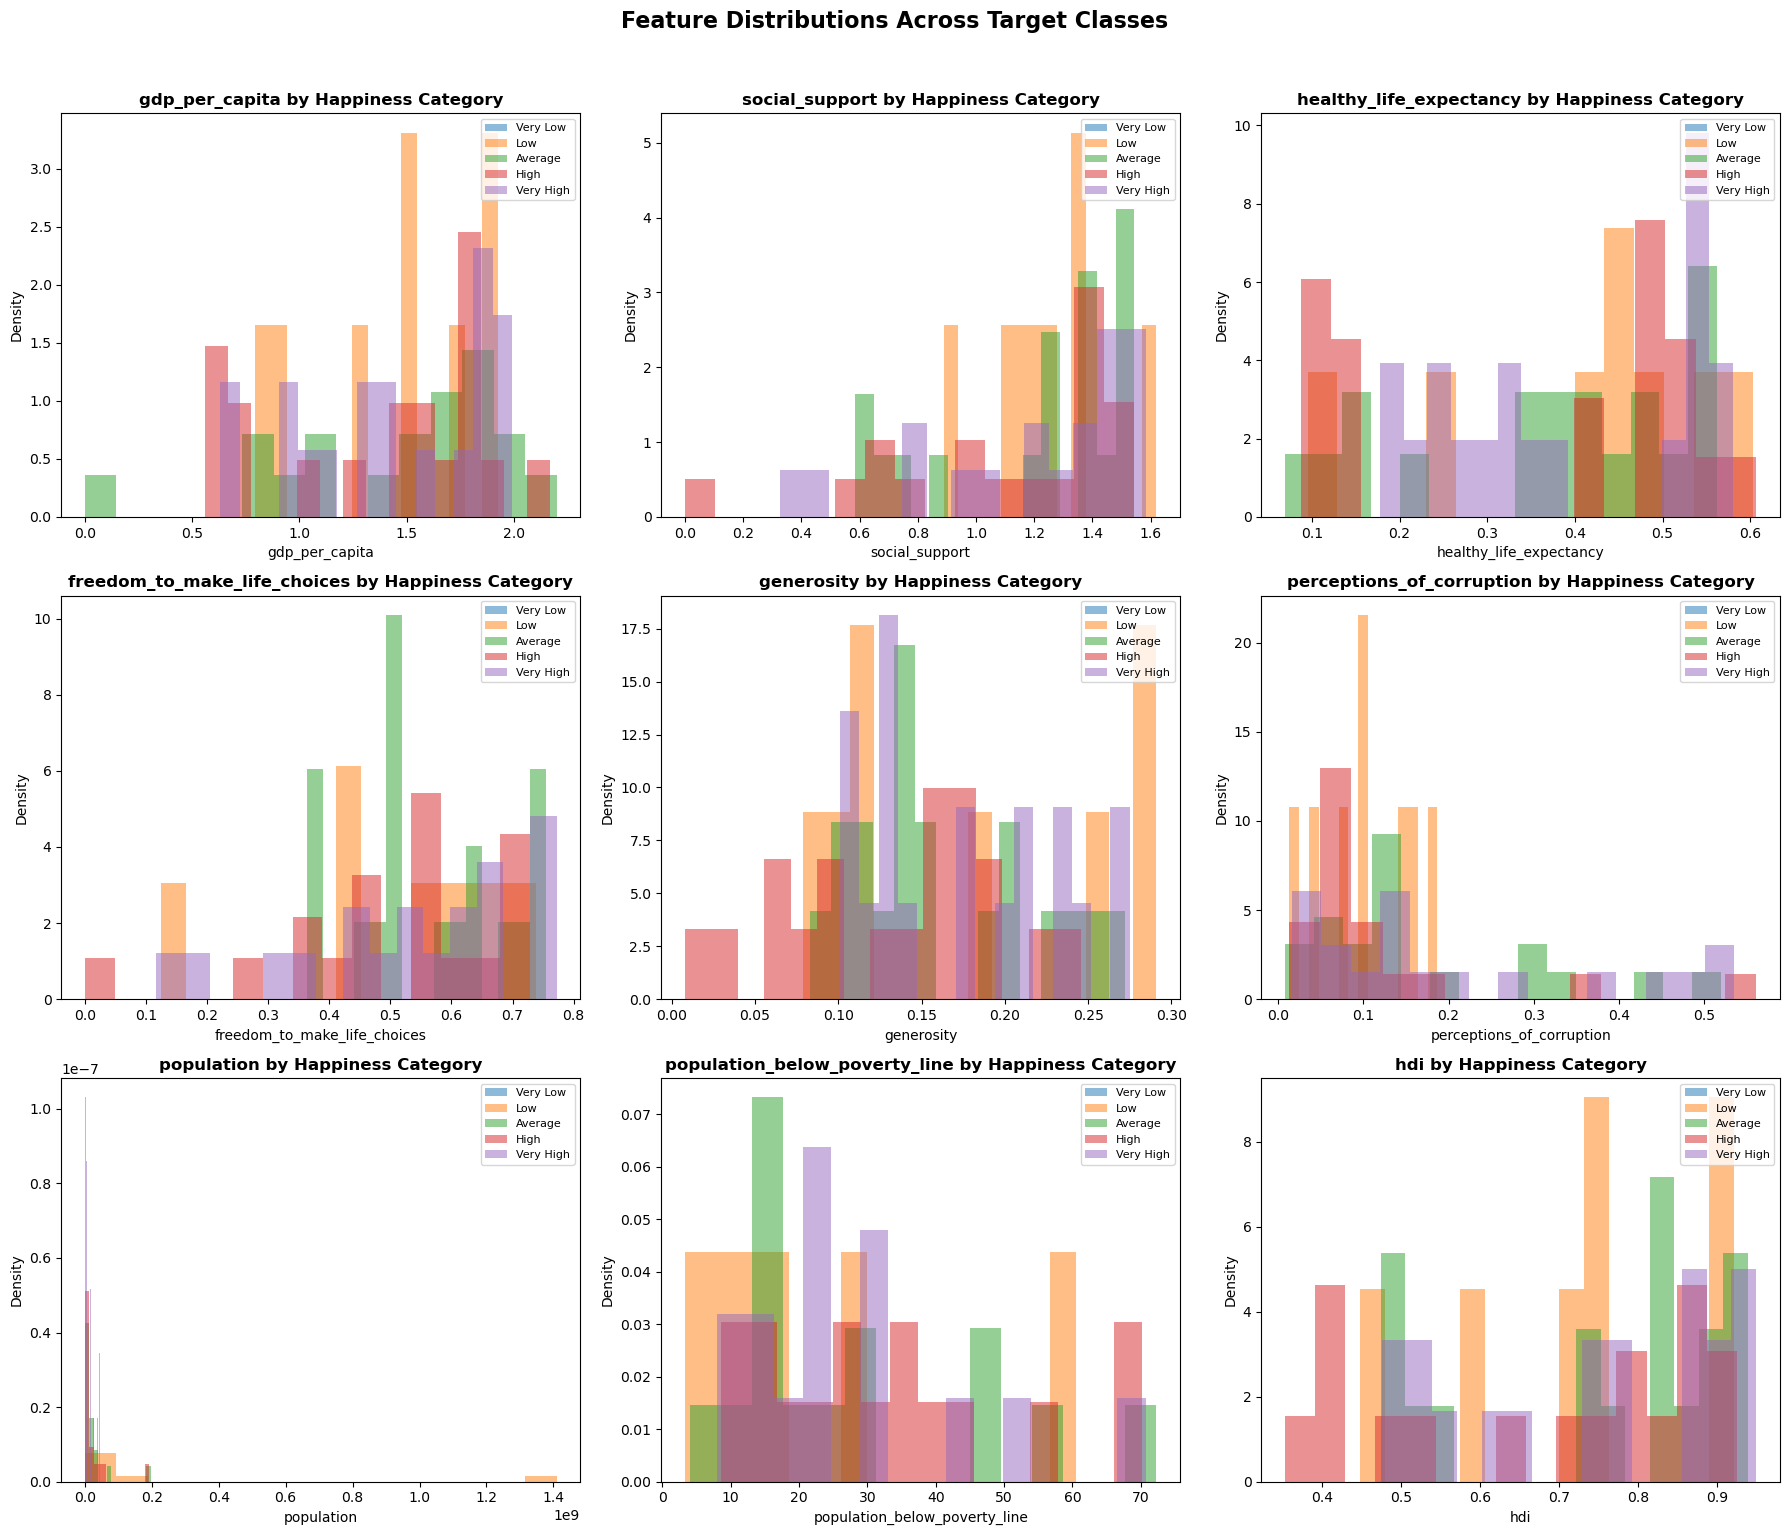

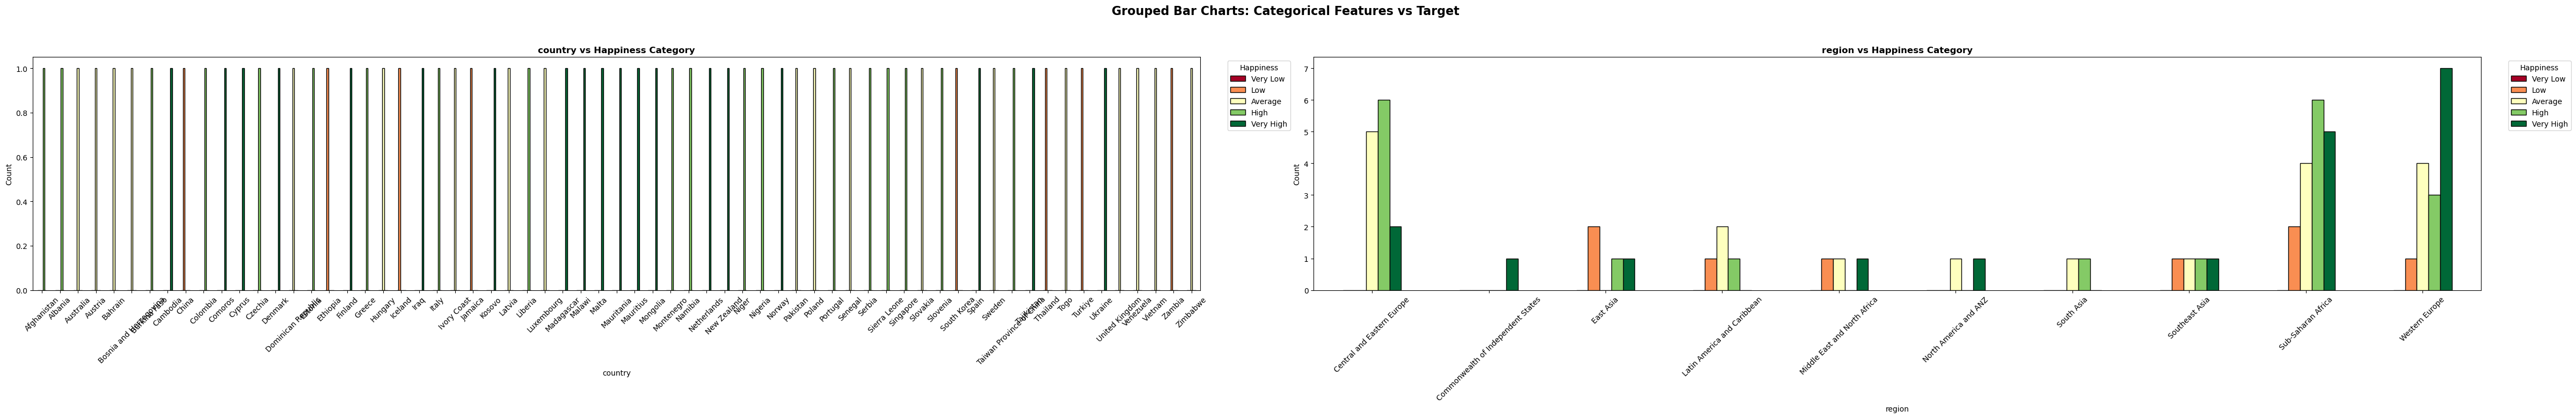

In [40]:

# Bivariate Analysis and Relationship Exploration
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

temp = X_train.copy()
temp['happiness_category'] = y_train
category = ['Very Low', 'Low', 'Average', 'High', 'Very High']

key_features = [c for c in num_cols if c in [
    'gdp_per_capita', 'social_support', 'healthy_life_expectancy',
    'freedom_to_make_life_choices', 'generosity', 'perceptions_of_corruption',
    'hdi', 'life_expectancy', 'population_below_poverty_line', 'population'
]][:9]

# Correlation table and heatmap
corr_df = temp[key_features + ['happiness_category']].copy()
# encode target for correlation
target_numeric = pd.Categorical(corr_df['happiness_category'], categories=category, ordered=True).codes
corr_df = corr_df[key_features].assign(happiness_category=target_numeric)
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Table (Key Features + Target)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation with target (happiness_category):")
print(corr['happiness_category'].drop('happiness_category').sort_values(ascending=False).round(3).to_string())

# Box plots: feature distributions across target classes
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()
for i, col in enumerate(key_features):
    sns.boxplot(data=temp, x='happiness_category', y=col, order=category, palette='RdYlGn', ax=axes[i])
    axes[i].set_title(f'{col} by Happiness Category', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Happiness Category')
    axes[i].tick_params(axis='x', rotation=45)
for j in range(len(key_features), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Bivariate Analysis: Box Plots (Feature vs Target)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Scatter/strip: feature vs target
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()
for i, col in enumerate(key_features):
    sns.stripplot(data=temp, x='happiness_category', y=col, order=category, palette='RdYlGn', jitter=0.25, size=6, alpha=0.6, ax=axes[i], edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'{col} vs Happiness Category', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Happiness Category')
    axes[i].tick_params(axis='x', rotation=45)
for j in range(len(key_features), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Bivariate Analysis: Scatter Distribution of Key Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Distribution comparison: KDE by target for key features
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()
for i, col in enumerate(key_features):
    for cat in category:
        subset = temp.loc[temp['happiness_category'] == cat, col].dropna()
        axes[i].hist(subset, bins=15, alpha=0.5, label=cat, density=True)
    axes[i].set_title(f'{col} by Happiness Category', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend(loc='upper right', fontsize=8)
for j in range(len(key_features), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Feature Distributions Across Target Classes', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#  Grouped bar charts (categorical features vs target)
cat_cols = [c for c in temp.columns if c not in num_cols and c != 'happiness_category' and temp[c].dtype in ['object', 'category']]
if cat_cols:
    n_cat = min(len(cat_cols), 4)
    fig, axes = plt.subplots(2, 2, figsize=(48, 12))
    axes = axes.flatten()
    for i, col in enumerate(cat_cols[:n_cat]):
        ct = pd.crosstab(temp[col], temp['happiness_category'])
        ct = ct.reindex(columns=category, fill_value=0)
        ct.plot(kind='bar', ax=axes[i], colormap='RdYlGn', edgecolor='black')
        axes[i].set_title(f'{col} vs Happiness Category', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].legend(title='Happiness', bbox_to_anchor=(1.02, 1), loc='upper left')
        axes[i].tick_params(axis='x', rotation=45)
    for j in range(n_cat, len(axes)):
        fig.delaxes(axes[j])
    plt.suptitle('Grouped Bar Charts: Categorical Features vs Target', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No categorical features found for grouped bar charts.")



### Outlier Detection

Identify potential outliers in the numerical features using appropriate methods such as:

- Box plots
- Z-score analysis
- Interquartile Range (IQR) method

Highlight any significant anomalies and briefly comment on whether they should be retained, transformed, or removed.

In [36]:
# Your code here: TODO

### Observations and General Comments

Summarize your key findings from the exploratory analysis. Include:

- Important patterns or relationships identified
- Presence of missing values or outliers
- Potential feature engineering considerations
- Any preprocessing steps that should be applied before modeling

Keep your comments concise and evidence-based.

*Replace this section with your response.*

**TODO**

---

## 2. Feature Engineering

Apply log transformations to normalize skewed numerical features and improve model stability (if applicable).

In [37]:
# Your code here: TODO

Create at least one interaction feature to capture relationships between existing variables and enhance predictive power.

In [38]:
# Your code here: TODO

---

## 3. Data Preprocessing

Use `sklearn`'s `ColumnTransformer` to preprocess the data. Write a preprocessing function and save the fitted preprocessor for later use.

In [39]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Create the preprocessing pipelines for both numeric and categorical data.

numeric_features = ## Drop all the non-numerical features from X_train: TODO
numeric_features=numeric_features.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)), ## Is this good enough?
    ('scaler', StandardScaler())]) # You will need to describe why this is being done in the next cell

categorical_features = ['region', 'sub-region']

#Replacing missing values with Modal value and then one hot encoding.
categorical_transformer = Pipeline(steps=[
    ('imputer',  ## Fill here: TODO)),
    ('onehot', OneHotEncoder(handle_unknown= ## Fill here: TODO))])

# final preprocessor object set up with ColumnTransformer
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features),('cat', categorical_transformer, categorical_features)])

#Fit your preprocessor object
preprocess=preprocessor.fit(X_train)

SyntaxError: invalid syntax (3852555583.py, line 9)

### Explanation

Briefly explain what the preprocessing steps above do and why they are needed.

If you changed the imputation strategy (or any other preprocessing choice), please state:

- What you changed
- Why you made that change

*Replace this section with your response.*

**TODO**

In [ ]:
# function to transform data with preprocessor

def preprocessor(data):
    data.drop(['country', 'region'], axis=1)
    preprocessed_data=preprocess.transform(data)
    return preprocessed_data

### Conceptual Question

Explain the differences between the following:

- The `preprocessor` **object**
- The `preprocess` **object**
- The `preprocessor` **function**
- The final `preprocessed_data` **returned**

Clearly distinguish between objects, functions, and transformed data.

*Replace this section with your response.*

**TODO**

In [ ]:
# check shape of X data after preprocessing it using our new function
preprocessor(X_train).shape

---

## 4. Model Training and Saving Artifacts

Fit the model on the preprocessed training data. Save the fitted preprocessor and the trained model for reuse (e.g., inference and submission).

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = ## Define a Random Forest Model here, fit it, and score it: TODO

# Your cell should have a score between 0-1 as output
# add your lines of code here: TODO

---

## 5. Model Evaluation

Generate predictions using `X_test`. Compare the predictions with the true labels in `y_test` using appropriate evaluation metrics.

In [ ]:
#-- Generate predicted values (Model 1)
prediction_labels = model.predict(preprocessor(X_test))

# Write lines of code to show model performance by comparing prediction_labels with true labels: TODO


---

## 6. Hyperparameter Experimentation

Repeat the training and evaluation process with different model parameters to improve performance. Track results across experiments and report the best-performing configuration.

In [ ]:
# Train model 2 using same preprocessor (note that you could save a new preprocessor, but we will use the same one for this example).
from sklearn.ensemble import RandomForestClassifier

model_2 = ## Make a new model with changed parameters to improve the score: TODO
# write your lines of code here TODO

### Reflection on Hyperparameter Changes

Briefly explain:

- What parameters you changed
- What each parameter controls
- Why the changes improved (or did not improve) performance

Support your explanation with evidence from your results.

*Replace this section with your response.*

**TODO**

In [ ]:
#Evaluate Model 2:

#-- Generate predicted y values (Model 2)
prediction_labels = # Predict : TODO

# Write lines of code below to show model performance by comparing prediction_labels with true labels: TODO


### Discussion Question

Do you think it is worth making more changes to the parameters? Should we keep trying random values and see what works better? What is an alternative to doing this manually?

*Replace this section with your response.*

**TODO**

In [ ]:
# Submit a third model using GridSearchCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np

param_grid = # Use np.arange to create a sequence of numbers for each parameter's space you think should be searched: TODO

# Create a RandomForestClassifier object TODO

gridmodel = # Read GridSearchCV docs and create an object with RandomForestClassifier as the model TODO

#Fit the GridSearchCV object to the preprocessed training data: TODO


#extract best score and parameter by calling objects "best_score_" and "best_params_"
print("best mean cross-validation score: {:.3f}".format(gridmodel.best_score_))
print("best parameters: {}".format(gridmodel.best_params_))

# Make predictions using the best model : TODO


In [ ]:
#Submit Model 3:

#-- Generate predicted values


## Write lines of code to show model performance by comparing prediction_labels with true labels: TODO


In [ ]:
# Here are several classic ML architectures you can consider choosing from to experiment with next:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier


model = ## Read documentations of imported models and fit them. TODO

#-- Generate predicted values
prediction_labels = model.predict(preprocessor(X_test))

## Write lines of code to show model performance by comparing prediction_labels with true labels: TODO


### Discussion Question

Describe the parameters you defined in `GradientBoostingClassifier`, and/or `BaggingClassifier`, and/or `KNN`, and/or `SVC`. What worked and why?

*Replace this section with your response.*

**TODO**

---

## 7. Basic Deep Learning

In [ ]:
# Now experiment with deep learning models:
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation

# Preprocess input features: TODO

feature_count=#count features in input data: TODO

keras_model = ## Define a Neural Network Model with 5 layers 128->64->64->32->(?) TODO


#Use Softmax activation in last layer. How many neurons should there be in the last layer?

# Encode categorical labels : TODO


# Compile model
keras_model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

# Fitting the NN to the Training set
keras_model.fit(preprocessor(X_train), y_train, ## Note that keras models require a one-hot-encoded y_train object
               batch_size = 20,
               epochs = 300, validation_split=0.25)

### Discussion Question

Which activation functions did you use in the hidden layers? Why was **softmax** used in the final layer?

*Replace this section with your response.*

**TODO**

### Discussion Question

Was it a good idea to train for 300 epochs? Should you train longer? Why or why not?

*Replace this section with your response.*

**TODO**

### Discussion Question

Why was `loss='categorical_crossentropy'` and `optimizer='sgd'` used? Would you change anything? Why or why not?

*Replace this section with your response.*

**TODO**

### Plot Training Curves

Extract the model training history and plot the learning curves (e.g., training vs. validation loss and accuracy) across epochs.

In [ ]:
## Your code to plot training and validation curves in a single plot (Make changes in the model cell to be able to do this) : TODO

In [ ]:
#-- Generate predicted y values

#Note: Keras predict returns the predicted column index location for classification models
prediction_column_index= # Predict TODO

# extract correct prediction labels
prediction_labels = [y_train.columns[i] for i in prediction_column_index]

## Write lines of code to show model performance by comparing prediction_labels with true labels: TODO


### Regularization: Dropout and Batch Normalization

Implement regularization techniques such as **Dropout** and **Batch Normalization** to improve generalization and observe the change in performance.

> **Note:** Compare training vs. test (or validation) loss and accuracy before and after adding regularization.

In [ ]:
# Write your lines of code here: TODO

*Replace this section with your response.*

**TODO**

### Activation Function Experimentation

Experiment with different activation functions — **ReLU**, **LeakyReLU**, **Tanh**, and **Sigmoid** — and compare their impact on model performance.

In [ ]:
# Your lines of code here: TODO

---

## 8. Explainability – SHAP Feature Importance

To better understand the model's predictions, we will use **SHAP (SHapley Additive exPlanations)** to analyze feature importance.

**How SHAP works:**

- SHAP assigns each feature a contribution score for every prediction.
- It uses Shapley values (from cooperative game theory) to fairly distribute importance across features.

We will apply SHAP to visualize and interpret the model's feature contributions.

In [ ]:
# Import necessary libraries
import shap
import matplotlib.pyplot as plt

# Initialize SHAP explainer: TODO
# Define an explainer that will help us interpret the model's decisions
# (Hint: Use shap.Explainer with the trained model and X_test data)

explainer = ## Initialize SHAP explainer using the trained model: TODO

# Compute SHAP values for X_test
# This step generates Shapley values, which explain how each feature contributes to predictions
shap_values = ## Apply the explainer to X_test: TODO

## Write lines of code here to transform the test data using the preprocessor : TODO
##and Generate generic feature names matching the number of columns after preprocessing : TODO

# Generate SHAP summary plot
# This plot will show which features have the most impact on predictions
shap.summary_plot(## Pass the required parameters to create a summary plot: TODO)

# Your cell should output a SHAP summary plot showing the most important features.


### Experimentation

In [ ]:
## You are encouraged to try more experimentation and any other models by adding more code cells to this notebook:

## You can also try to import any new dataset pertaining to countries, merge it, and see if it helps the predictions.
## If it does not, try to explain why it wasn't helpful by exploring variable relationships.

Deep learning models are often considered "black boxes" due to their complexity. Use SHAP to explain your model's predictions.

After applying SHAP, discuss:

- Does it provide a clear and sufficient explanation of how the model makes decisions?
- How easy or difficult is it to justify your model's predictions using this technique?

In [ ]:
## Your lines of Code and Answer: TODO

*Replace this section with your response.*

**TODO**

---

## 9. Final Report Submission (GitHub)

This is your final project to showcase on GitHub.

### Instructions

1. Create a new notebook for the final report.
2. Include relevant visualizations.
3. Reproduce the code for the best-performing model(s) and display results.
4. Summarize key insights and observed behaviors.
5. Present the work in a clean, concise report format (within the `.ipynb`).
6. Upload the final notebook to a new repository on your personal GitHub account.
7. Paste the link to your final repository at the top of this notebook where requested.